# Elementwise Flow vs MAF

A very small toy example to illustrate one core point:

- an **elementwise flow** can learn flexible **marginals**,
- but it cannot create **dependence** between coordinates,
- while a **masked autoregressive flow (MAF)** can.

We fit both models on the same 2D synthetic target.

## Target distribution

We generate data from

$$
z_1, z_2 \sim \mathcal N(0,1),
$$

$$
x_1 = 1.4 z_1,
\qquad
x_2 = 0.25 z_2 + 0.9\sin(1.2 z_1).
$$

So the two coordinates are clearly dependent: the mass lies on a curved band.

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import torch
from zuko.distributions import DiagNormal
from zuko.flows import ElementWiseTransform, Flow, MAF, UnconditionalDistribution
from zuko.transforms import MonotonicRQSTransform

plt.style.use('default')
torch.manual_seed(7)
device = torch.device('cpu')


def sample_target(n: int) -> torch.Tensor:
    z1 = torch.randn(n, device=device)
    z2 = torch.randn(n, device=device)
    x1 = 1.4 * z1
    x2 = 0.25 * z2 + 0.9 * torch.sin(1.2 * z1)
    return torch.stack((x1, x2), dim=-1)


def plot_cloud(ax, x: torch.Tensor, title: str, xlim=None, ylim=None):
    x_np = x.detach().cpu().numpy()
    ax.scatter(x_np[:, 0], x_np[:, 1], s=8, alpha=0.25, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.2)


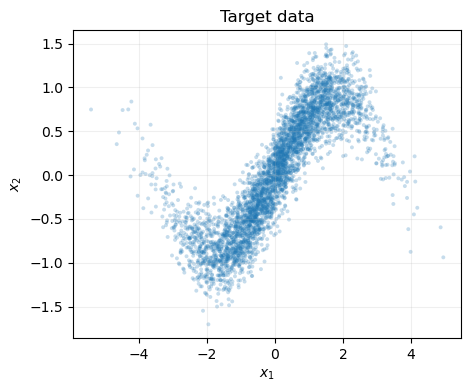

In [2]:
train_x = sample_target(4000)
test_x = sample_target(1000)

fig, ax = plt.subplots(figsize=(5, 4))
plot_cloud(ax, train_x, 'Target data')
plt.show()

## Why an elementwise flow is limited

If the base density factorizes,

$$
p_U(u) = \prod_{i=1}^D p_{U_i}(u_i),
$$

and we transform each coordinate independently,

$$
x_i = h_i(u_i),
$$

then the learned density also factorizes:

$$
p_X(x) = \prod_{i=1}^D p_{U_i}(h_i^{-1}(x_i))\left|\frac{d}{dx_i} h_i^{-1}(x_i)\right|.
$$

So an elementwise flow can make each marginal flexible, but it still cannot model the joint dependence structure.

## Models

To make the comparison fair, both models use the same **scalar spline transform**.

The only difference is the dependence structure:

- **Elementwise flow**: each coordinate is transformed independently.
- **MAF**: the transform for coordinate $i$ can depend on previous coordinates.

In [3]:
bins = 8
univariate = partial(MonotonicRQSTransform, slope=1e-3)
shapes = [(bins,), (bins,), (bins - 1,)]


def make_elementwise_flow() -> Flow:
    return Flow(
        ElementWiseTransform(
            features=2,
            univariate=univariate,
            shapes=shapes,
        ),
        UnconditionalDistribution(
            DiagNormal,
            loc=torch.zeros(2),
            scale=torch.ones(2),
            buffer=True,
        ),
    ).to(device)


def make_maf() -> MAF:
    return MAF(
        features=2,
        transforms=4,
        hidden_features=(64, 64),
        univariate=univariate,
        shapes=shapes,
    ).to(device)


elementwise_flow = make_elementwise_flow()
maf_flow = make_maf()

In [4]:
def fit_flow(flow, train_x, test_x, steps=400, lr=5e-3):
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    train_losses = []

    for step in range(steps):
        optimizer.zero_grad()
        loss = -flow().log_prob(train_x).mean()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    test_nll = -flow().log_prob(test_x).mean().item()
    return train_losses, test_nll


elem_history, elem_test_nll = fit_flow(elementwise_flow, train_x, test_x)
maf_history, maf_test_nll = fit_flow(maf_flow, train_x, test_x)

print(f'Elementwise flow test NLL: {elem_test_nll:.3f}')
print(f'MAF test NLL:              {maf_test_nll:.3f}')

Elementwise flow test NLL: 2.712
MAF test NLL:              1.822


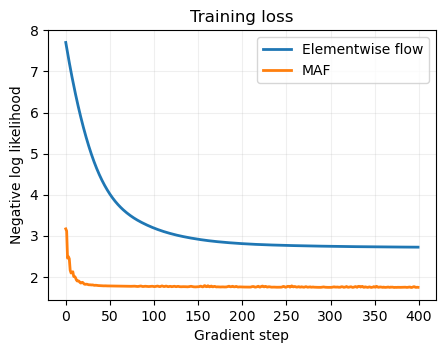

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(elem_history, label='Elementwise flow', lw=2)
ax.plot(maf_history, label='MAF', lw=2)
ax.set_title('Training loss')
ax.set_xlabel('Gradient step')
ax.set_ylabel('Negative log likelihood')
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## Compare samples

If the story above is correct, the elementwise flow should roughly match the one-dimensional marginals but miss the curved dependence.

The MAF should recover the curved joint structure much better.

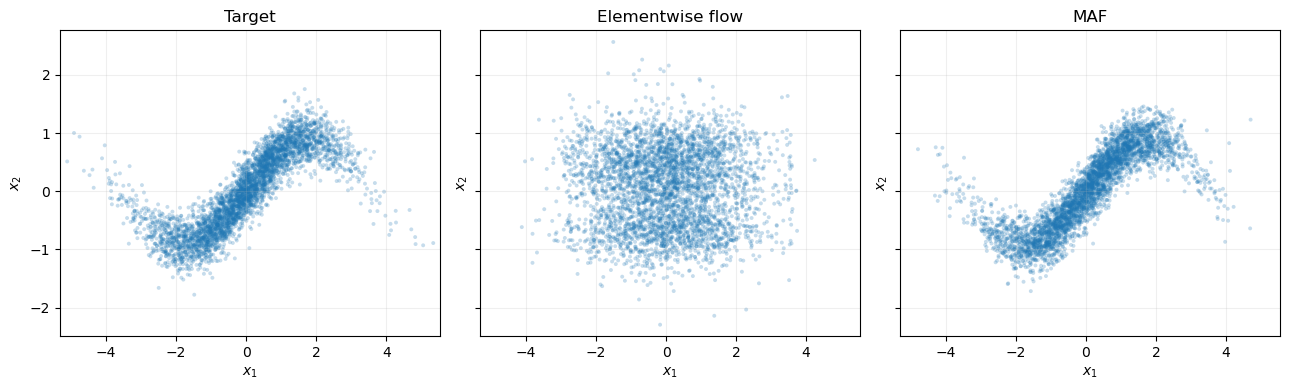

In [6]:
with torch.no_grad():
    target_samples = sample_target(4000)
    elem_samples = elementwise_flow().sample((4000,))
    maf_samples = maf_flow().sample((4000,))

all_x = torch.cat([target_samples, elem_samples, maf_samples], dim=0)
pad = 0.2
xlim = (all_x[:, 0].min().item() - pad, all_x[:, 0].max().item() + pad)
ylim = (all_x[:, 1].min().item() - pad, all_x[:, 1].max().item() + pad)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
plot_cloud(axes[0], target_samples, 'Target', xlim=xlim, ylim=ylim)
plot_cloud(axes[1], elem_samples, 'Elementwise flow', xlim=xlim, ylim=ylim)
plot_cloud(axes[2], maf_samples, 'MAF', xlim=xlim, ylim=ylim)
plt.tight_layout()
plt.show()

## Take-away

- The **elementwise flow** is already flexible in each coordinate, because we used spline bijections.
- But it still cannot create dependence, so its learned joint distribution stays too simple.
- The **MAF** changes only one thing: each coordinate can depend on the previous ones.
- That is enough to capture the curved structure and improve the held-out likelihood.

This is exactly the reason MAF is a useful next step after introducing elementwise flows in the slides.